# Toy TB microsimulation (SELT(R))

This notebook implements the SELT(R) disease natural history as a **discrete-time stochastic microsimulation** (individual-level model). Each agent is an integer in a state array; transitions happen probabilistically at monthly time steps using vectorized NumPy operations. For TB epidemiology background see `tb_overview/modeling_tb.pdf`.

## Model structure

The SELT(R) microsimulation tracks the same six biological states as the ODE model. Each agent holds one integer label $\in \{S, L_\text{fast}, L_\text{slow}, I, T, R\}$. At every monthly time step $\Delta t = 1/12$ year, each agent transitions stochastically according to the probabilities below.

For a rate $r$, the exact probability of at least one event in $\Delta t$ under an exponential waiting-time assumption is:
$$p = 1 - e^{-r \,\Delta t}$$

**Competing risks** are handled sequentially with a single uniform draw $u \sim \text{Uniform}(0,1)$ per agent. For the infectious compartment, the four exits are assigned non-overlapping probability intervals:

| Agent state | Transition | Probability (per $\Delta t$) |
|---|---|---|
| $S$ | $\to L_\text{fast}$ | $f \cdot (1 - e^{-\lambda \Delta t})$ |
| $S$ | $\to L_\text{slow}$ | $(1-f) \cdot (1 - e^{-\lambda \Delta t})$ |
| $S$ | $\to \text{dead}$ | $1 - e^{-\mu \Delta t}$ |
| $L_\text{fast}$ | $\to I$ | $1 - e^{-\nu_\text{fast} \Delta t}$ |
| $L_\text{slow}$ | $\to I$ | $1 - e^{-\nu_\text{slow} \Delta t}$ |
| $I$ | $\to T$ | $1 - e^{-\tau \Delta t}$ |
| $I$ | $\to R$ | $1 - e^{-\gamma \Delta t}$ |
| $I$ | $\to \text{dead (TB)}$ | $1 - e^{-\delta \Delta t}$ |
| $T$ | $\to I$ (relapse) | $1 - e^{-\rho_T \Delta t}$ |
| $R$ | $\to I$ (reactivation) | $1 - e^{-\rho_R \Delta t}$ |

Force of infection: $\lambda = \beta \, I / N_\text{alive}$.

$$
\frac{dS}{dt} = bN - \lambda S - \mu S
$$

$$
\frac{dL_\text{fast}}{dt} = f \lambda S - \nu_\text{fast} L_\text{fast} - \mu L_\text{fast}
$$

$$
\frac{dL_\text{slow}}{dt} = (1 - f) \lambda S - \nu_\text{slow} L_\text{slow} - \mu L_\text{slow}
$$

$$
\frac{dI}{dt} = \nu_\text{fast} L_\text{fast} + \nu_\text{slow} L_\text{slow} + \rho_T T + \rho_R R - (\tau + \gamma + \delta + \mu) I
$$

$$
\frac{dT}{dt} = \tau I - \rho_T T - \mu T
$$

$$
\frac{dR}{dt} = \gamma I - \rho_R R - \mu R
$$

## Basic reproduction number

$R_0$ is a property of the infection process, not the simulation algorithm, so the same next-generation-matrix formula applies here:

$$
R_0 = \beta \cdot \frac{1}{\tau + \gamma + \delta + \mu} \cdot \left( f \cdot \frac{\nu_\text{fast}}{\nu_\text{fast} + \mu} + (1 - f) \cdot \frac{\nu_\text{slow}}{\nu_\text{slow} + \mu} \right)
$$

The three factors are: the transmission rate $\beta$, the mean infectious duration $1/(\tau+\gamma+\delta+\mu)$, and the probability that a new infection eventually reaches $I$ (weighted fast/slow). Unlike the deterministic ODE, the microsimulation allows stochastic extinction even when $R_0 > 1$ — particularly in small populations.

$$
R_0 = \beta \cdot \frac{1}{\tau + \gamma + \delta + \mu} \cdot \left( f \cdot \frac{\nu_\text{fast}}{\nu_\text{fast} + \mu} + (1 - f) \cdot \frac{\nu_\text{slow}}{\nu_\text{slow} + \mu} \right)
$$

The three terms are: the transmission rate $\beta$, the mean infectious duration $1/(\tau + \gamma + \delta + \mu)$, and the probability that a new infection eventually reaches the infectious compartment (weighted sum over fast and slow progressors).

## Default parameters

Identical to the ODE model — same biology, same parameter values. `n_agents = 50,000` is used instead of 1 million for laptop speed (a single 50-year simulation runs in ~5 seconds).

| Parameter | Symbol | Value | Units | Source / note |
|---|---|---|---|---|
| Agents | $N$ | 50,000 | persons | laptop-scale toy default |
| Time step | $\Delta t$ | 1/12 | years | monthly |
| Birth rate | $b$ | 1/70 | 1/year | ~70-year life expectancy |
| Natural death rate | $\mu$ | 1/70 | 1/year | ~70-year life expectancy |
| Transmission rate | $\beta$ | 12 | 1/year | yields plausible $R_0$ |
| Fast-progressor fraction | $f$ | 0.10 | — | Vynnycky & Fine 1997 |
| Fast progression rate | $\nu_\text{fast}$ | 2.0 | 1/year | progression within months |
| Slow reactivation rate | $\nu_\text{slow}$ | 0.001 | 1/year | long-term reactivation |
| Treatment rate | $\tau$ | 1.0 | 1/year | mean 1-year delay to treatment |
| Self-cure rate | $\gamma$ | 0.2 | 1/year | Tiemersma et al. 2011 |
| TB mortality rate | $\delta$ | 0.2 | 1/year | Tiemersma et al. 2011 |
| Relapse after treatment | $\rho_T$ | 0.02 | 1/year | toy value |
| Reactivation after self-cure | $\rho_R$ | 0.01 | 1/year | toy value |roject default |
| Birth rate | $b$ | 1/70 | 1/year | ~70-year life expectancy |
| Natural death rate | $\mu$ | 1/70 | 1/year | ~70-year life expectancy |
| Transmission rate | $\beta$ | 12 | 1/year | yields plausible $R_0$ |
| Fast-progressor fraction | $f$ | 0.10 | — | 5–10% early progression (Vynnycky & Fine 1997) |
| Fast progression rate | $\nu_\text{fast}$ | 2.0 | 1/year | progression within months (Vynnycky & Fine 1997) |
| Slow reactivation rate | $\nu_\text{slow}$ | 0.001 | 1/year | long-term reactivation (Vynnycky & Fine 1997) |
| Treatment rate | $\tau$ | 1.0 | 1/year | mean 1-year delay to treatment |
| Self-cure rate | $\gamma$ | 0.2 | 1/year | ~5-year mean self-cure (Tiemersma et al. 2011) |
| TB mortality rate | $\delta$ | 0.2 | 1/year | ~50% 3-year fatality (Tiemersma et al. 2011) |
| Relapse after treatment | $\rho_T$ | 0.02 | 1/year | toy value |
| Reactivation after self-cure | $\rho_R$ | 0.01 | 1/year | toy value |

In [15]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.model import compute_basic_reproduction_number, run_replications, run_simulation
from src.parameters import ModelParameters
from src.plotting import plot_compartment_timeseries, plot_incident_active_tb, plot_replications


In [16]:
parameters = ModelParameters()

r0 = compute_basic_reproduction_number(parameters)
print(f"R0 (toy model): {r0:.2f}")
print(f"Agents: {parameters.n_agents:,}")
print(f"Time step: {parameters.time_step_years:.4f} years ({parameters.time_step_years * 12:.1f} months)")

results = run_simulation(parameters, time_horizon_years=50.0, seed=42)

final_prev = results["prevalence_infectious"][-1] * 1000
print(f"\nFinal infectious prevalence: {final_prev:.2f} per 1,000")

R0 (toy model): 1.34
Agents: 50,000
Time step: 0.0833 years (1.0 months)

Final infectious prevalence: 0.00 per 1,000


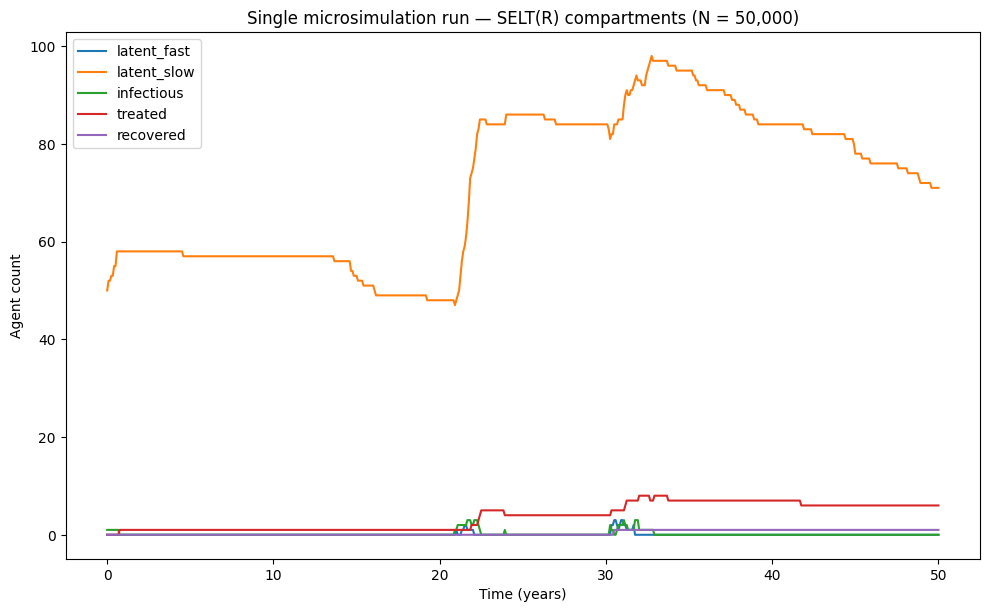

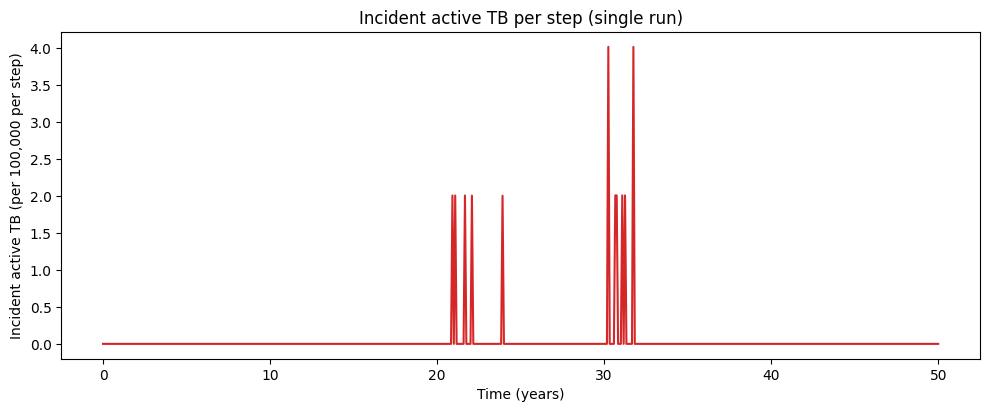

In [17]:
# Single simulation — all compartments
plot_compartment_timeseries(
    results,
    compartment_names=["latent_fast", "latent_slow", "infectious", "treated", "recovered"],
)
plt.title("Single microsimulation run — SELT(R) compartments (N = 50,000)")
plt.show()

# Incidence
plot_incident_active_tb(results, per_100k=True)
plt.title("Incident active TB per step (single run)")
plt.show()

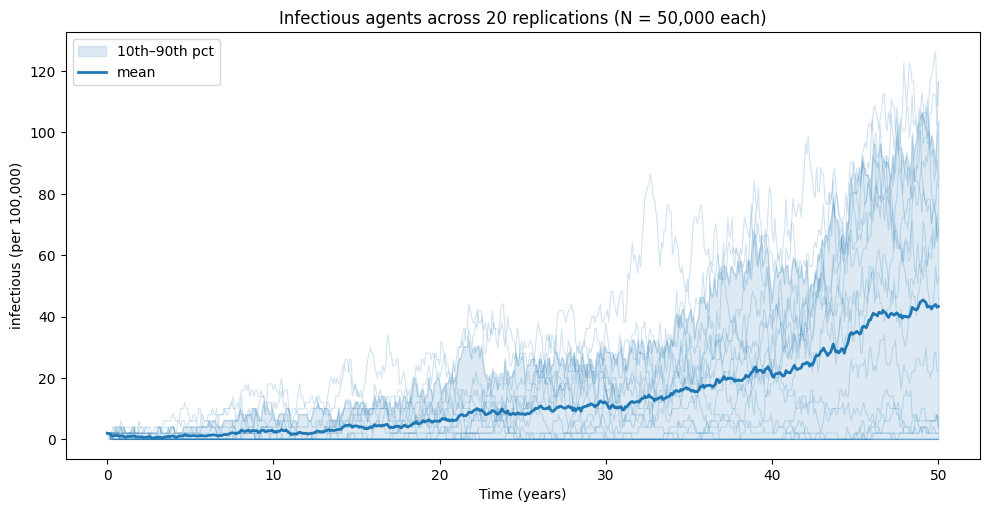

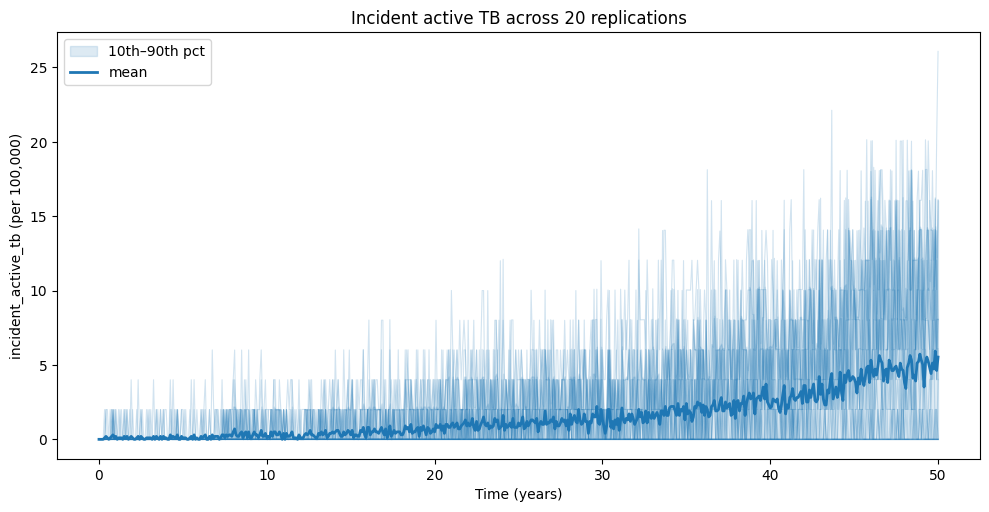

In [18]:
# 20 replications — shows stochastic variability around the mean trajectory
reps = run_replications(parameters, n_replications=20, time_horizon_years=50.0, base_seed=0)

plot_replications(reps, compartment="infectious", per_100k=True)
plt.title("Infectious agents across 20 replications (N = 50,000 each)")
plt.show()

plot_replications(reps, compartment="incident_active_tb", per_100k=True)
plt.title("Incident active TB across 20 replications")
plt.show()

Stochastic extinction in 25/30 runs at N=500 (R0=1.34)


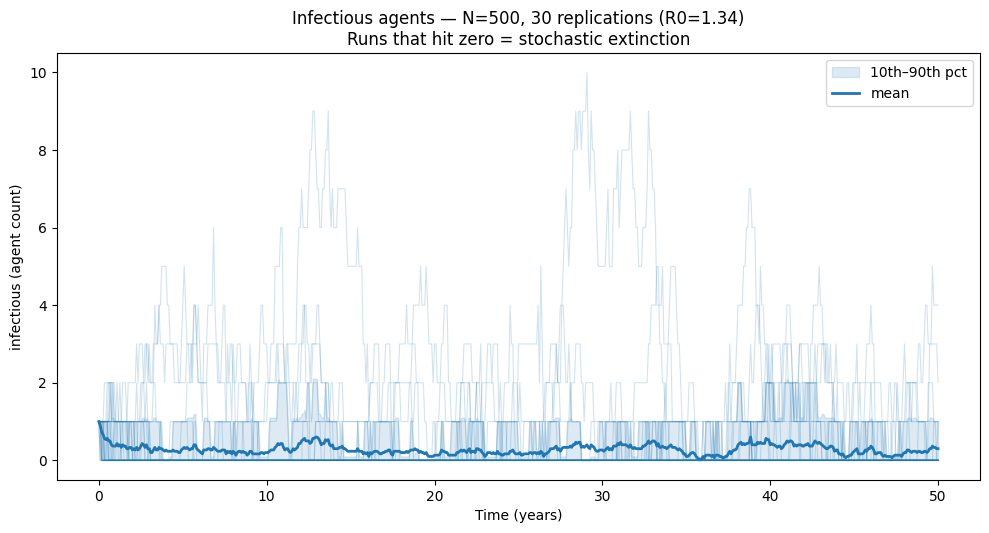

In [19]:
# Stochastic extinction in a small population
# With N=500, even R0 > 1 allows the outbreak to die out by chance

small_parameters = ModelParameters(n_agents=500)
small_reps = run_replications(small_parameters, n_replications=30, time_horizon_years=50.0, base_seed=100)

n_extinct = sum(r["infectious"][-1] == 0 for r in small_reps)
print(f"Stochastic extinction in {n_extinct}/30 runs at N=500 (R0={compute_basic_reproduction_number(small_parameters):.2f})")

plot_replications(small_reps, compartment="infectious")
plt.title(f"Infectious agents — N=500, 30 replications (R0={r0:.2f})\nRuns that hit zero = stochastic extinction")
plt.show()